# 🤖 Intelligent Research Assistant

## Objectives

- Load extracted research paper
- Generate summary
- Extract keywords
- Visualize important words

In [1]:
import os
import sys
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import utils.preprocessing
importlib.reload(utils.preprocessing)

from utils.preprocessing import preprocess, text_statistics

In [2]:
import sys
print(sys.executable)

c:\Python314\python.exe


In [3]:
%pip install wordcloud yake sumy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import yake

from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [5]:
with open("../uploads/extracted_text.txt","r",encoding="utf-8") as f:
    paper = f.read()

print("Characters:",len(paper))

Characters: 39495


In [6]:
parser = PlaintextParser.from_string(paper, Tokenizer("english"))

summarizer = LsaSummarizer()

summary = summarizer(parser.document,8)

print("===== SUMMARY =====\n")

for sentence in summary:
    print(sentence)

===== SUMMARY =====

We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.
Self-attention has been used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22].
We also experimented with using learned positional embeddings [9] instead, and found that the two versions produced nearly identical results (see Table 3 row (E)).
A single convolutional layer with kernel width k < n does not connect all pairs of input and output positions.
While single-head attention is 0.9 BLEU worse than the best setting, quality also drops off with too many heads.
We also trained it in a semi-supervised setting, using the larger high-confidence and BerkleyParser corpora from with approximately 17M sentences [37].
For translation tasks, the Transformer can be trained significantly f

In [7]:
kw_extractor = yake.KeywordExtractor()

keywords = kw_extractor.extract_keywords(paper)

print("Top Keywords\n")

for keyword, score in keywords[:20]:
    print(keyword)

Top Keywords

Attention
arXiv preprint arXiv
model
models
Transformer
Neural machine translation
scaled dot-product attention
sequence
layer
arXiv
arXiv preprint
preprint arXiv
Neural Information Processing
output
neural
layers
neural networks
dot-product attention
multi-head attention
sequence transduction models


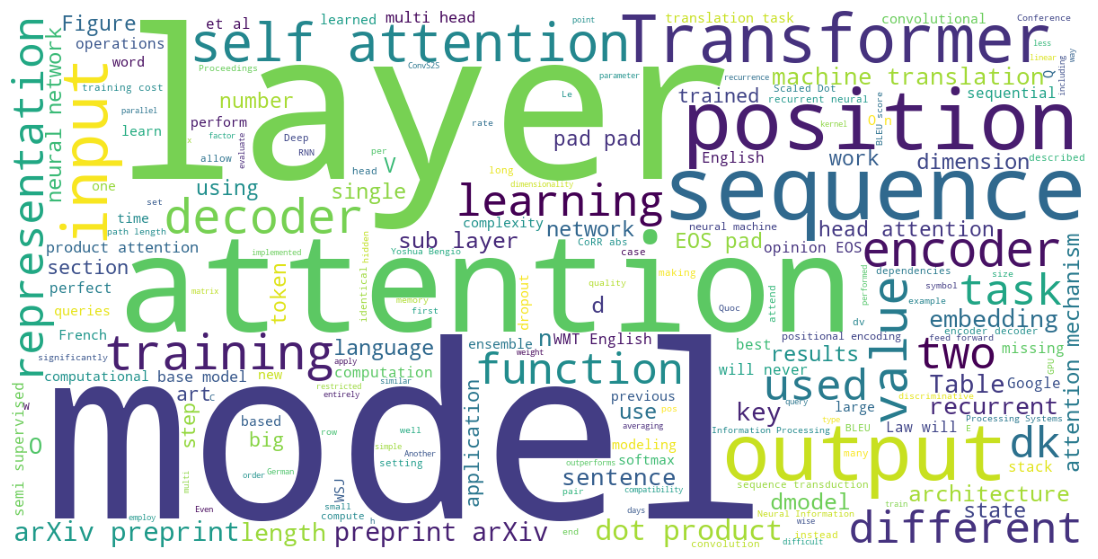

In [8]:
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(paper)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [9]:
from collections import Counter
import re

words = re.findall(r"\b[a-zA-Z]{4,}\b", paper.lower())

common = Counter(words)

common.most_common(20)

[('attention', 93),
 ('model', 45),
 ('this', 42),
 ('sequence', 40),
 ('with', 39),
 ('models', 37),
 ('layer', 36),
 ('arxiv', 33),
 ('output', 29),
 ('layers', 29),
 ('transformer', 28),
 ('self', 28),
 ('neural', 27),
 ('encoder', 27),
 ('training', 27),
 ('decoder', 26),
 ('input', 24),
 ('translation', 23),
 ('that', 22),
 ('positions', 22)]

In [10]:
import pandas as pd

freq = pd.DataFrame(
    common.most_common(20),
    columns=["Word","Frequency"]
)

freq

,Word,Frequency
0,attention,93
1,model,45
2,this,42
3,sequence,40
4,with,39
5,models,37
6,layer,36
7,arxiv,33
8,output,29
9,layers,29


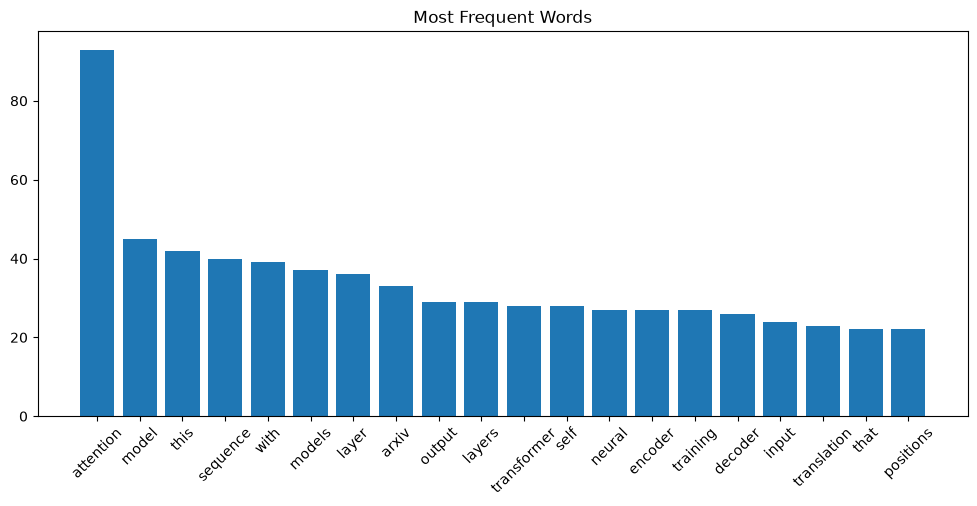

In [11]:
plt.figure(figsize=(12,5))

plt.bar(freq["Word"],freq["Frequency"])

plt.xticks(rotation=45)

plt.title("Most Frequent Words")

plt.show()

In [12]:
with open("../utils/preprocessing.py", "r", encoding="utf-8") as f:
    print(f.read())

"""
Text Preprocessing Functions
AI Research Paper Intelligence System
"""

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download resources (only first time)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Basic text cleaning.
    """

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


def tokenize(text):
    """
    Tokenize text into words.
    """

    return word_tokenize(text)


def remove_stopwords(tokens):
    """
    Remove stopwords.
    """

    return [
        word
        for word in tokens
        if word not in stop_words
    ]


def lemmatize(tokens):
    """
    Lemmatize tokens.

In [13]:
import utils.preprocessing as prep

print(dir(prep))

['WordNetLemmatizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'clean_text', 'lemmatize', 'lemmatizer', 'nltk', 'preprocess', 're', 'remove_stopwords', 'stop_words', 'stopwords', 'text_statistics', 'tokenize', 'word_tokenize']


In [14]:
import utils.preprocessing as prep

print(prep.__file__)

c:\Users\srina\OneDrive\Desktop\ResearchMind-AI\utils\preprocessing.py


In [15]:
import sys
sys.path.append("..")

In [16]:
with open("../utils/preprocessing.py", "r", encoding="utf-8") as f:
    content = f.read()

print(content)

"""
Text Preprocessing Functions
AI Research Paper Intelligence System
"""

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download resources (only first time)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Basic text cleaning.
    """

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()


def tokenize(text):
    """
    Tokenize text into words.
    """

    return word_tokenize(text)


def remove_stopwords(tokens):
    """
    Remove stopwords.
    """

    return [
        word
        for word in tokens
        if word not in stop_words
    ]


def lemmatize(tokens):
    """
    Lemmatize tokens.

In [17]:
import sys
sys.path.append("..")

import utils.preprocessing as prep

print(dir(prep))

['WordNetLemmatizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'clean_text', 'lemmatize', 'lemmatizer', 'nltk', 'preprocess', 're', 'remove_stopwords', 'stop_words', 'stopwords', 'text_statistics', 'tokenize', 'word_tokenize']


In [18]:
import importlib
import utils.preprocessing as prep

print(prep.__file__)

importlib.reload(prep)

print(dir(prep))

c:\Users\srina\OneDrive\Desktop\ResearchMind-AI\utils\preprocessing.py
['WordNetLemmatizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'clean_text', 'lemmatize', 'lemmatizer', 'nltk', 'preprocess', 're', 'remove_stopwords', 'stop_words', 'stopwords', 'text_statistics', 'tokenize', 'word_tokenize']


In [19]:
import utils

print(utils)
print(utils.__file__)


<module 'utils' from 'c:\\Users\\srina\\OneDrive\\Desktop\\ResearchMind-AI\\utils\\__init__.py'>
c:\Users\srina\OneDrive\Desktop\ResearchMind-AI\utils\__init__.py


In [20]:
import os

print(os.getcwd())

c:\Users\srina\OneDrive\Desktop\ResearchMind-AI\notebooks


In [21]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import importlib
import utils.preprocessing

importlib.reload(utils.preprocessing)

from utils.preprocessing import preprocess, text_statistics

print("Imported successfully!")

Imported successfully!


In [22]:
import os
import sys
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import utils.summarizer
importlib.reload(utils.summarizer)

from utils.summarizer import PaperSummarizer

print("✅ Summarizer imported!")

✅ Summarizer imported!


In [23]:
from utils.pdf_utils import extract_text_from_pdf

text = extract_text_from_pdf(
    "../uploads/attention_is_all_you_need.pdf"
)

In [24]:
summarizer = PaperSummarizer()

summary = summarizer.summarize(
    text,
    sentences=8
)

for i, sentence in enumerate(summary, start=1):
    print(f"{i}. {sentence}\n")

1. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.

2. Self-attention has been used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22].

3. We also experimented with using learned positional embeddings [9] instead, and found that the two versions produced nearly identical results (see Table 3 row (E)).

4. A single convolutional layer with kernel width k < n does not connect all pairs of input and output positions.

5. While single-head attention is 0.9 BLEU worse than the best setting, quality also drops off with too many heads.

6. We also trained it in a semi-supervised setting, using the larger high-confidence and BerkleyParser corpora from with approximately 17M sentences [37].

7. During inference, we 9 Table 4: The Transformer generalizes wel

In [25]:
keywords = summarizer.keywords(
    text,
    top_n=15
)

keywords

[('Attention', np.float64(0.002281332880254446)),
 ('arXiv preprint arXiv', np.float64(0.0029772532632492497)),
 ('model', np.float64(0.003981807394706982)),
 ('models', np.float64(0.004735122307219113)),
 ('Transformer', np.float64(0.005507254120990095)),
 ('Neural machine translation', np.float64(0.006994225757574728)),
 ('scaled dot-product attention', np.float64(0.007410522315444337)),
 ('sequence', np.float64(0.007748219216389736)),
 ('layer', np.float64(0.008425689415123998)),
 ('arXiv', np.float64(0.008558083450232614)),
 ('arXiv preprint', np.float64(0.008925973303449608)),
 ('preprint arXiv', np.float64(0.008925973303449608)),
 ('Neural Information Processing', np.float64(0.009416944007073933)),
 ('output', np.float64(0.009471960871327904)),
 ('neural', np.float64(0.009785871124582636))]

In [26]:
[
 ('Transformer', 0.001),
 ('Attention', 0.003),
 ('Machine Translation', 0.005),
 ('Encoder', 0.006),
 ...
]

[('Transformer', 0.001),
 ('Attention', 0.003),
 ('Machine Translation', 0.005),
 ('Encoder', 0.006),
 Ellipsis]

In [27]:
import os
import sys
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import utils.analytics
importlib.reload(utils.analytics)

from utils.analytics import PaperAnalytics

In [28]:
from utils.pdf_utils import extract_text_from_pdf

paper = extract_text_from_pdf(
    "../uploads/attention_is_all_you_need.pdf"
)

In [29]:
from utils.pdf_utils import extract_text_from_pdf

paper = extract_text_from_pdf(
    "../uploads/attention_is_all_you_need.pdf"
)

In [30]:
analytics = PaperAnalytics(paper)

In [31]:
analytics.statistics()

{'Characters': 39498,
 'Words': 4584,
 'Unique Words': 1328,
 'Estimated Reading Time (minutes)': 22.92}

In [32]:
analytics.frequent_words()

,Word,Frequency
0,the,338
1,and,177
2,attention,93
3,for,51
4,model,45
5,this,42
6,sequence,40
7,with,39
8,models,37
9,layer,36


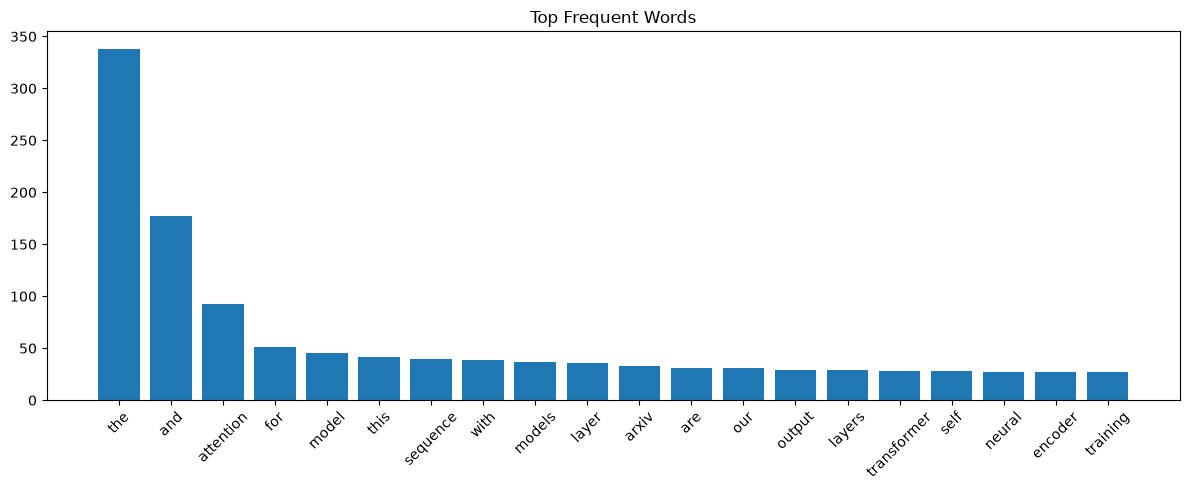

In [33]:
analytics.plot_frequency()

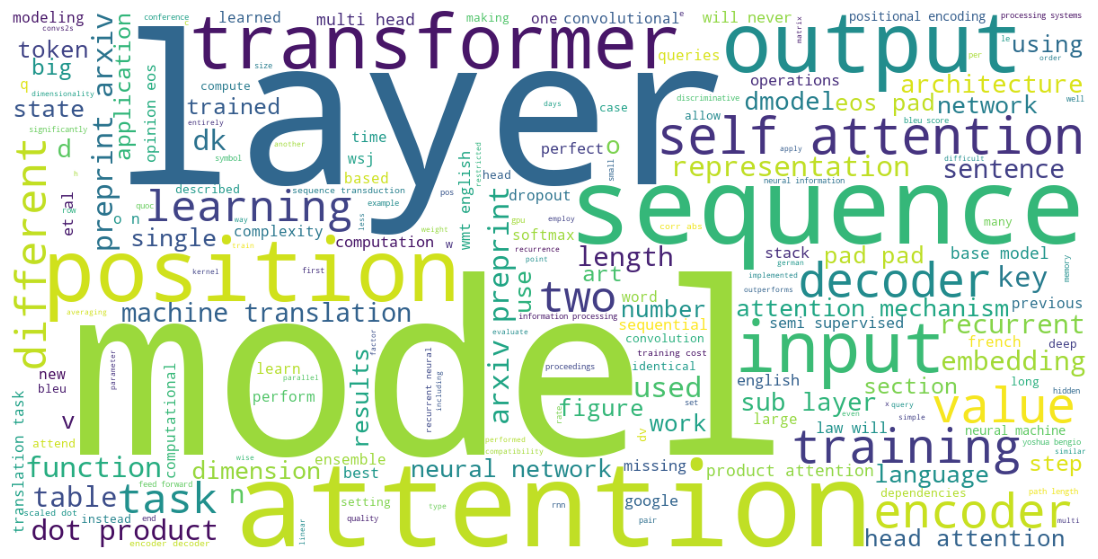

In [34]:
analytics.word_cloud()

In [35]:
import os
import sys
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import utils.citation
importlib.reload(utils.citation)

from utils.citation import CitationGenerator

In [36]:
citation = CitationGenerator(
    title="Attention Is All You Need",
    authors="Ashish Vaswani et al.",
    year="2017"
)

In [37]:
print(citation.apa())

Ashish Vaswani et al. (2017). Attention Is All You Need.


In [38]:
print(citation.ieee())

Ashish Vaswani et al., "Attention Is All You Need," 2017.


In [39]:
print(citation.mla())

Ashish Vaswani et al.. "Attention Is All You Need." 2017.
